In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [16]:
import os

dataset_path = "/content/drive/MyDrive/GCP_Assignment_Datasets"
train_path = dataset_path + "/content/drive/MyDrive/GCP_Assignment_Datasets/train_dataset"
test_path = dataset_path + "/content/drive/MyDrive/GCP_Assignment_Datasets/test_dataset"
label_path = "/content/drive/MyDrive/GCP_Assignment_Datasets/train_dataset/gcp_marks.json"

In [10]:
import os
os.listdir("/content/drive/MyDrive/GCP_Assignment_Datasets")

['train_dataset', 'test_dataset']

In [18]:
import os
import json
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
import torch.nn as nn

In [20]:
with open(label_path) as f:
    labels = json.load(f)
print("Total labeled images:", len(labels))

Total labeled images: 1000


In [13]:
import os
os.listdir("/content/drive/MyDrive/GCP_Assignment_Datasets")

['train_dataset', 'test_dataset']

In [14]:
os.listdir("/content/drive/MyDrive/GCP_Assignment_Datasets/train_dataset")

['gcp_marks.json',
 'Egypt-New city',
 '231129_CTD',
 'Seashell Ras el Hekma',
 'Deora Limestone Mine',
 'Vedanta GOA Bicholim',
 'UTCL UNCL Additional Area',
 'RDCW-Reddipalayam Limestone Mine',
 'scout_966',
 'Adani GP-III CG',
 'scout_973',
 'scout_971']

In [22]:
import json

with open(label_path) as f:
    labels = json.load(f)

print(type(labels))
print(len(labels))

<class 'dict'>
1000


In [23]:
sample = list(labels.keys())[0]

print(sample)
print(labels[sample])

scout_971/a61f66617a8dcf132dcc2cfa/GCP-11/DJI_20240301143538_0057_V.JPG
{'mark': {'x': 3272.769145523532, 'y': 1089.3292198344861}, 'verified_shape': 'Cross'}


In [24]:
from collections import Counter
shapes = []
for key in labels:
    if "verified_shape" in labels[key]:
        shapes.append(labels[key]["verified_shape"])
print(Counter(shapes))

Counter({'L-Shape': 491, 'Square': 328, 'Cross': 177})


In [26]:
xs = []
ys = []

for key in labels:
    xs.append(labels[key]["mark"]["x"])
    ys.append(labels[key]["mark"]["y"])

print("Min X:", min(xs))
print("Max X:", max(xs))

print("Min Y:", min(ys))
print("Max Y:", max(ys))

Min X: 66.96412957110547
Max X: 3937.0554836417386
Min Y: 35.044623574285524
Max Y: 2914.109404383081


In [33]:
img_path = train_path + "/" + sample

print(img_path)
print(os.path.exists(img_path))

img = cv2.imread(img_path)

print("Loaded:", img is not None)

/content/drive/MyDrive/GCP_Assignment_Datasets/content/drive/MyDrive/GCP_Assignment_Datasets/train_dataset/scout_971/a61f66617a8dcf132dcc2cfa/GCP-11/DJI_20240301143538_0057_V.JPG
False
Loaded: False


In [34]:
print(sample)

scout_971/a61f66617a8dcf132dcc2cfa/GCP-11/DJI_20240301143538_0057_V.JPG


In [35]:
dataset_path = "/content/drive/MyDrive/GCP_Assignment_Datasets"
train_path = dataset_path + "/train_dataset"
test_path = dataset_path + "/test_dataset"

In [36]:
img_path = train_path + "/" + sample

print(img_path)
print(os.path.exists(img_path))

/content/drive/MyDrive/GCP_Assignment_Datasets/train_dataset/scout_971/a61f66617a8dcf132dcc2cfa/GCP-11/DJI_20240301143538_0057_V.JPG
True


In [37]:
img = cv2.imread(img_path)

if img is None:
    print("Image failed to load")
else:
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

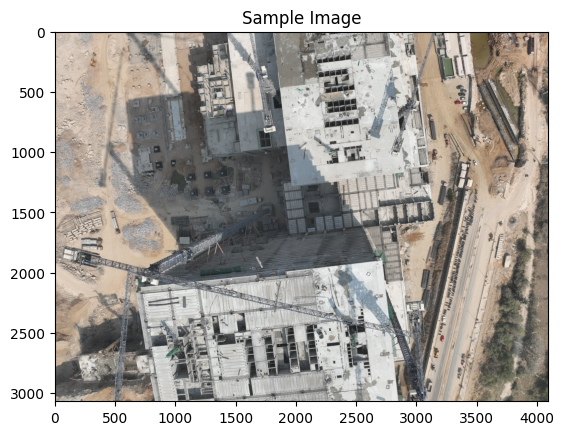

In [38]:
plt.imshow(img)
plt.title("Sample Image")
plt.show()

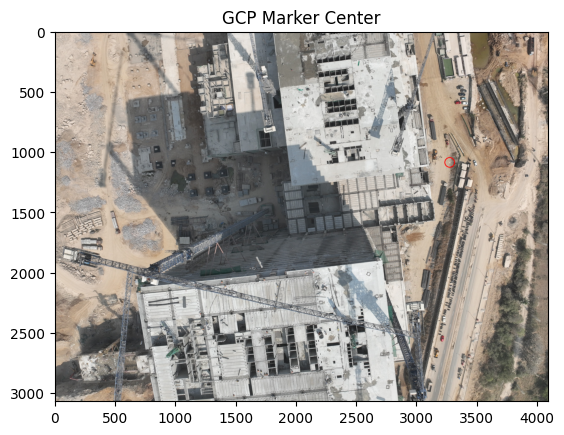

In [39]:
x = labels[sample]["mark"]["x"]
y = labels[sample]["mark"]["y"]

cv2.circle(img,(int(x),int(y)),40,(255,0,0),5)

plt.imshow(img)
plt.title("GCP Marker Center")
plt.show()

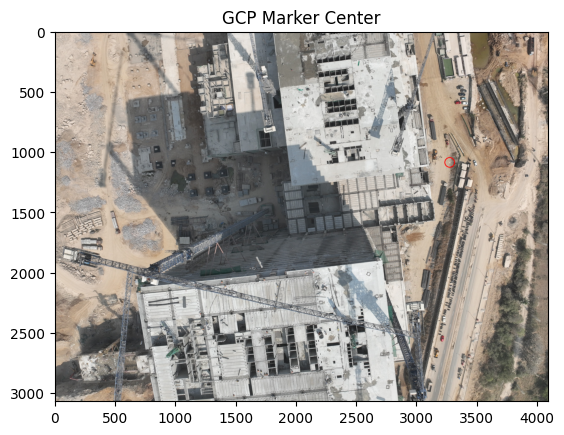

In [40]:
x = labels[sample]["mark"]["x"]
y = labels[sample]["mark"]["y"]

cv2.circle(img,(int(x),int(y)),40,(255,0,0),5)

plt.imshow(img)
plt.title("GCP Marker Center")
plt.show()

In [41]:
shape_map = {
    "Cross": 0,
    "Square": 1,
    "L-Shape": 2
}

reverse_map = {v: k for k, v in shape_map.items()}

In [42]:
import torch
import torchvision.transforms as transforms
import torchvision.models as models
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader

In [43]:
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

In [44]:
class GCPDataset(Dataset):

    def __init__(self, root, labels, transform=None):
        self.root = root
        self.labels = labels
        self.paths = list(labels.keys())
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):

        path = self.paths[idx]

        img = cv2.imread(self.root + "/" + path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        h, w, _ = img.shape

        label = self.labels[path]

        x = label["mark"]["x"]
        y = label["mark"]["y"]

        # scale coordinates for resized image
        x = x * 224 / w
        y = y * 224 / h

        shape = shape_map[label["verified_shape"]]

        img = cv2.resize(img, (224,224))

        if self.transform:
            img = self.transform(img)

        return img, torch.tensor([x,y],dtype=torch.float32), torch.tensor(shape)

In [45]:
dataset = GCPDataset(train_path, labels, transform)

print("Dataset size:", len(dataset))

Dataset size: 1000


In [46]:
loader = DataLoader(dataset, batch_size=8, shuffle=True)

In [47]:
class GCPModel(nn.Module):

    def __init__(self):

        super().__init__()

        backbone = models.resnet18(pretrained=True)

        self.features = nn.Sequential(*list(backbone.children())[:-1])

        self.fc_xy = nn.Linear(512,2)

        self.fc_shape = nn.Linear(512,3)

    def forward(self,x):

        x = self.features(x)

        x = x.view(x.size(0),-1)

        xy = self.fc_xy(x)

        shape = self.fc_shape(x)

        return xy,shape

In [48]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = GCPModel().to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 56.1MB/s]


In [49]:
mse = nn.MSELoss()

ce = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

In [54]:
class GCPDataset(Dataset):

    def __init__(self, root, labels, transform=None):

        self.root = root
        self.transform = transform

        # keep only valid samples
        self.data = []

        for path in labels:
            if "verified_shape" in labels[path]:
                self.data.append((path, labels[path]))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):

        path, label = self.data[idx]

        img = cv2.imread(self.root + "/" + path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        h, w, _ = img.shape

        x = label["mark"]["x"]
        y = label["mark"]["y"]

        # scale coordinates
        x = x * 224 / w
        y = y * 224 / h

        shape = shape_map[label["verified_shape"]]

        img = cv2.resize(img, (224,224))

        if self.transform:
            img = self.transform(img)

        return img, torch.tensor([x,y],dtype=torch.float32), torch.tensor(shape)

In [55]:
dataset = GCPDataset(train_path, labels, transform)

print("Dataset size:", len(dataset))

Dataset size: 996


In [56]:
loader = DataLoader(dataset, batch_size=8, shuffle=True)

In [59]:
loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

In [60]:
epochs = 3

for epoch in range(epochs):

    total_loss = 0

    for images,xy,shape in loader:

        images = images.to(device)
        xy = xy.to(device)
        shape = shape.to(device)

        pred_xy,pred_shape = model(images)

        loss_xy = mse(pred_xy,xy)
        loss_shape = ce(pred_shape,shape)

        loss = loss_xy + loss_shape

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}  Loss: {total_loss:.2f}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 1/3  Loss: 438431.90
Epoch 2/3  Loss: 430847.53
Epoch 3/3  Loss: 414176.67


In [61]:
torch.save(model.state_dict(), "gcp_model.pth")
print("Model saved")

Model saved


In [62]:
import os
def get_images(folder):
    images = []
    for root, dirs, files in os.walk(folder):
        for f in files:
            if f.lower().endswith(".jpg"):
                images.append(os.path.join(root, f))
    return images
test_images = get_images(test_path)
print("Total test images:", len(test_images))

Total test images: 300


In [63]:
model.eval()

GCPModel(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=Tru

In [65]:
results = {}

for path in test_images:

    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    h,w,_ = img.shape

    img_resized = cv2.resize(img,(224,224))

    img_tensor = transform(img_resized).unsqueeze(0).to(device)

    xy,shape = model(img_tensor)

    shape = torch.argmax(shape).item()

In [67]:
x = xy[0][0].item() * w / 224
y = xy[0][1].item() * h / 224

In [68]:
rel_path = os.path.relpath(path,test_path)

results[rel_path] = {
    "mark":{
        "x":float(x),
        "y":float(y)
    },
    "verified_shape":reverse_map[shape]
}

In [69]:
import json

with open("predictions.json","w") as f:
    json.dump(results,f,indent=4)

print("predictions.json created")

predictions.json created


In [70]:
import os

print(os.path.exists("predictions.json"))

True


In [71]:
import json

with open("predictions.json") as f:
    data = json.load(f)

print(len(data))

for i,(k,v) in enumerate(data.items()):
    print(k,v)
    if i==3:
        break

1
Aditya Limestone Mine/Jan Survey 2025/GCP-15/DJI_20250126111931_0065_V.JPG {'mark': {'x': 225.41728864397322, 'y': 171.07323569910866}, 'verified_shape': 'L-Shape'}


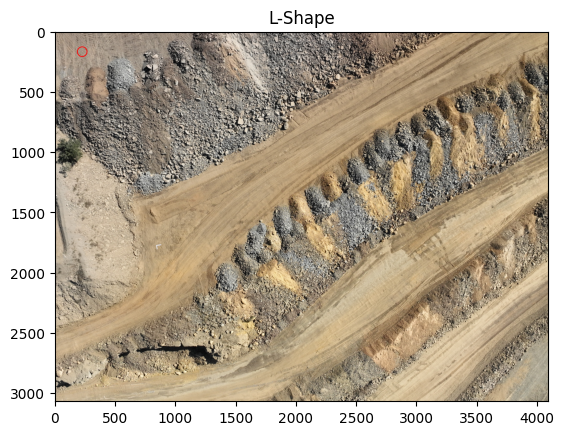

In [72]:
import random

sample_path = random.choice(list(data.keys()))

img_path = test_path + "/" + sample_path

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

x = data[sample_path]["mark"]["x"]
y = data[sample_path]["mark"]["y"]

cv2.circle(img,(int(x),int(y)),40,(255,0,0),5)

plt.imshow(img)
plt.title(data[sample_path]["verified_shape"])
plt.show()